# Stockout Analysis & Demand Censoring Correction

A **stockout** occurs when customer demand exceeds the available inventory. The key distinction is:

| Quantity | Definition |
|---|---|
| **True demand** | What customers *would* buy if stock were unlimited |
| **Available storage** | How many units are on hand at the start of a period |
| **Realised demand** | `min(true_demand, storage)` — what customers *actually* buy |
| **Lost sales** | `max(true_demand − storage, 0)` — units the retailer could not fulfil |
| **Stockout indicator** | `true_demand > storage` |

## Scenario: the growing store problem

This notebook simulates a store whose demand grows **non-linearly** over two years.  
The replenishment policy, and maximum storage, is sized for Year-1 demand and left unchanged — so the store sails through Year 1 without incident, but stockouts begin accumulating as Year-2 demand accelerates past the fixed reorder quantity.

The critical consequence of stockouts is **demand censoring**: on stockout days the observed sales record shows `storage` (the inventory cap), not the true demand. A forecaster trained naively on this censored sales history will systematically underestimate demand, perpetuating the problem.

This notebook:
1. Generates a two-year synthetic demand series with non-linear growth, seasonality, and noise.
2. Simulates a fixed replenishment policy that becomes insufficient over time.
3. Visualises how censoring distorts the sales signal.
4. Fits a Bayesian structural state space model in two conditions — **raw** (biased) vs **NaN-masked** (corrected) — to quantify how much of the true demand trend can be recovered.
5. Fits a **linear Bayesian model** (`BayesTimeSeries`) under the same two conditions — **raw** vs **`pm.Censored`** — to show the correction is model-agnostic.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

---
## 1. Synthetic Data Generation

We simulate **two years** of daily data for a single SKU at a growing store.

### True demand — non-linear growth
$$d_t = \underbrace{\mu_0 + \mu_g \left(\frac{t}{T-1}\right)^{\gamma}}_{\text{accelerating trend}} + \underbrace{A_{\text{week}} \sin\!\left(\tfrac{2\pi t}{7}\right)}_{\text{weekly cycle}} + \underbrace{A_{\text{year}} \sin\!\left(\tfrac{2\pi t}{365}\right)}_{\text{annual cycle}} + \varepsilon_t$$

With $\gamma > 1$ the growth curve is **convex** — slow at the start, then accelerating — mimicking a store gaining popularity. The replenishment policy uses a fixed `Q` every `R` days, sized for Year-1 demand. As true demand accelerates into Year 2, `Q` becomes insufficient and stockouts emerge.

### Storage (inventory on hand)
$$s_t = \max(s_{t-1} - \min(d_t, s_{t-1}),\; 0) + \mathbb{1}[t \bmod R = 0] \cdot Q$$

In [2]:
# ── Parameters ────────────────────────────────────────────────────────────
N            = 730          # 2 years of daily data
dates        = pd.date_range("2023-01-01", periods=N, freq="D")
t            = np.arange(N)

# Non-linear demand growth — convex curve (slow start, accelerating)
mu_base      = 50           # baseline daily demand at launch (units)
mu_growth    = 90           # total demand increment over 2 years
growth_exp   = 1.7          # γ > 1 → convex growth (the higher, the more back-loaded)

# Seasonality & noise
amp_weekly   = 10           # weekly seasonality amplitude
amp_yearly   = 15           # annual seasonality amplitude
sigma        = 7            # noise std

# Fixed replenishment policy — calibrated for Year-1 demand, never revised
reorder_qty  = 125        # units ordered per replenishment
reorder_freq = 1            # replenish every 7 days
max_storage  = 125         # maximum storage capacity (units)

# ── True demand ───────────────────────────────────────────────────────────
growth      = mu_growth * (t / (N - 1)) ** growth_exp   # convex non-linear trend
weekly      = amp_weekly * np.sin(2 * np.pi * t / 7)
yearly      = amp_yearly * np.sin(2 * np.pi * t / 365)
noise       = np.random.normal(0, sigma, N)

true_demand = np.maximum(mu_base + growth + weekly + yearly + noise, 0).round(1)

# ── Simulate inventory & realised demand ──────────────────────────────────
storage           = np.zeros(N)
realised_demand   = np.zeros(N)
lost_sales        = np.zeros(N)
stockout_flag     = np.zeros(N, dtype=bool)

inventory = 0.0             # stock starts empty; first replenishment arrives day 0

for i in range(N):
    if i % reorder_freq == 0:
        inventory += reorder_qty

    storage[i]         = np.min([inventory, max_storage])  # actual storage is limited by max capacity
    sold               = min(true_demand[i], storage[i])  # can only sell up to what's in storage
    realised_demand[i] = sold
    lost_sales[i]      = true_demand[i] - sold
    stockout_flag[i]   = true_demand[i] > storage[i]
    inventory          = max(storage[i] - sold, 0)

# ── Build DataFrame ───────────────────────────────────────────────────────
df = pd.DataFrame({
    "date":             dates,
    "true_demand":      true_demand,
    "storage":          storage,
    "realised_demand":  realised_demand,
    "lost_sales":       lost_sales,
    "stockout":         stockout_flag,
})

print(f"Days simulated       : {N}  ({N//365} years)")
print(f"Year 1 stockout days : {stockout_flag[:365].sum():3d}  ({stockout_flag[:365].mean():.1%} of Year 1)")
print(f"Year 2 stockout days : {stockout_flag[365:].sum():3d}  ({stockout_flag[365:].mean():.1%} of Year 2)")
print(f"Total lost sales     : {lost_sales.sum():,.0f} units")
df.head(10).round(1)

Days simulated       : 730  (2 years)
Year 1 stockout days :   0  (0.0% of Year 1)
Year 2 stockout days :  36  (9.9% of Year 2)
Total lost sales     : 350 units


,date,true_demand,storage,realised_demand,lost_sales,stockout
0,2023-01-01,53.5,125.0,53.5,0.0,False
1,2023-01-02,57.1,125.0,57.1,0.0,False
2,2023-01-03,64.8,125.0,64.8,0.0,False
3,2023-01-04,65.8,125.0,65.8,0.0,False
4,2023-01-05,45.1,125.0,45.1,0.0,False
5,2023-01-06,39.9,125.0,39.9,0.0,False
6,2023-01-07,54.8,125.0,54.8,0.0,False
7,2023-01-08,57.2,125.0,57.2,0.0,False
8,2023-01-09,56.6,125.0,56.6,0.0,False
9,2023-01-10,65.9,125.0,65.9,0.0,False


---
## 2. Visualising the Stockout Dynamics

The plot below shows four panels:

1. **True vs Realised demand** — the gap between the two lines is lost sales; stockout days are shaded red.
2. **Inventory on hand** — the sawtooth pattern of depletions and replenishments.
3. **Daily lost sales** — units not fulfilled on each day.
4. **Cumulative lost sales** — total revenue-at-risk that accumulates over the year.

C:\Users\bouwe\AppData\Local\Temp\ipykernel_45280\176285516.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


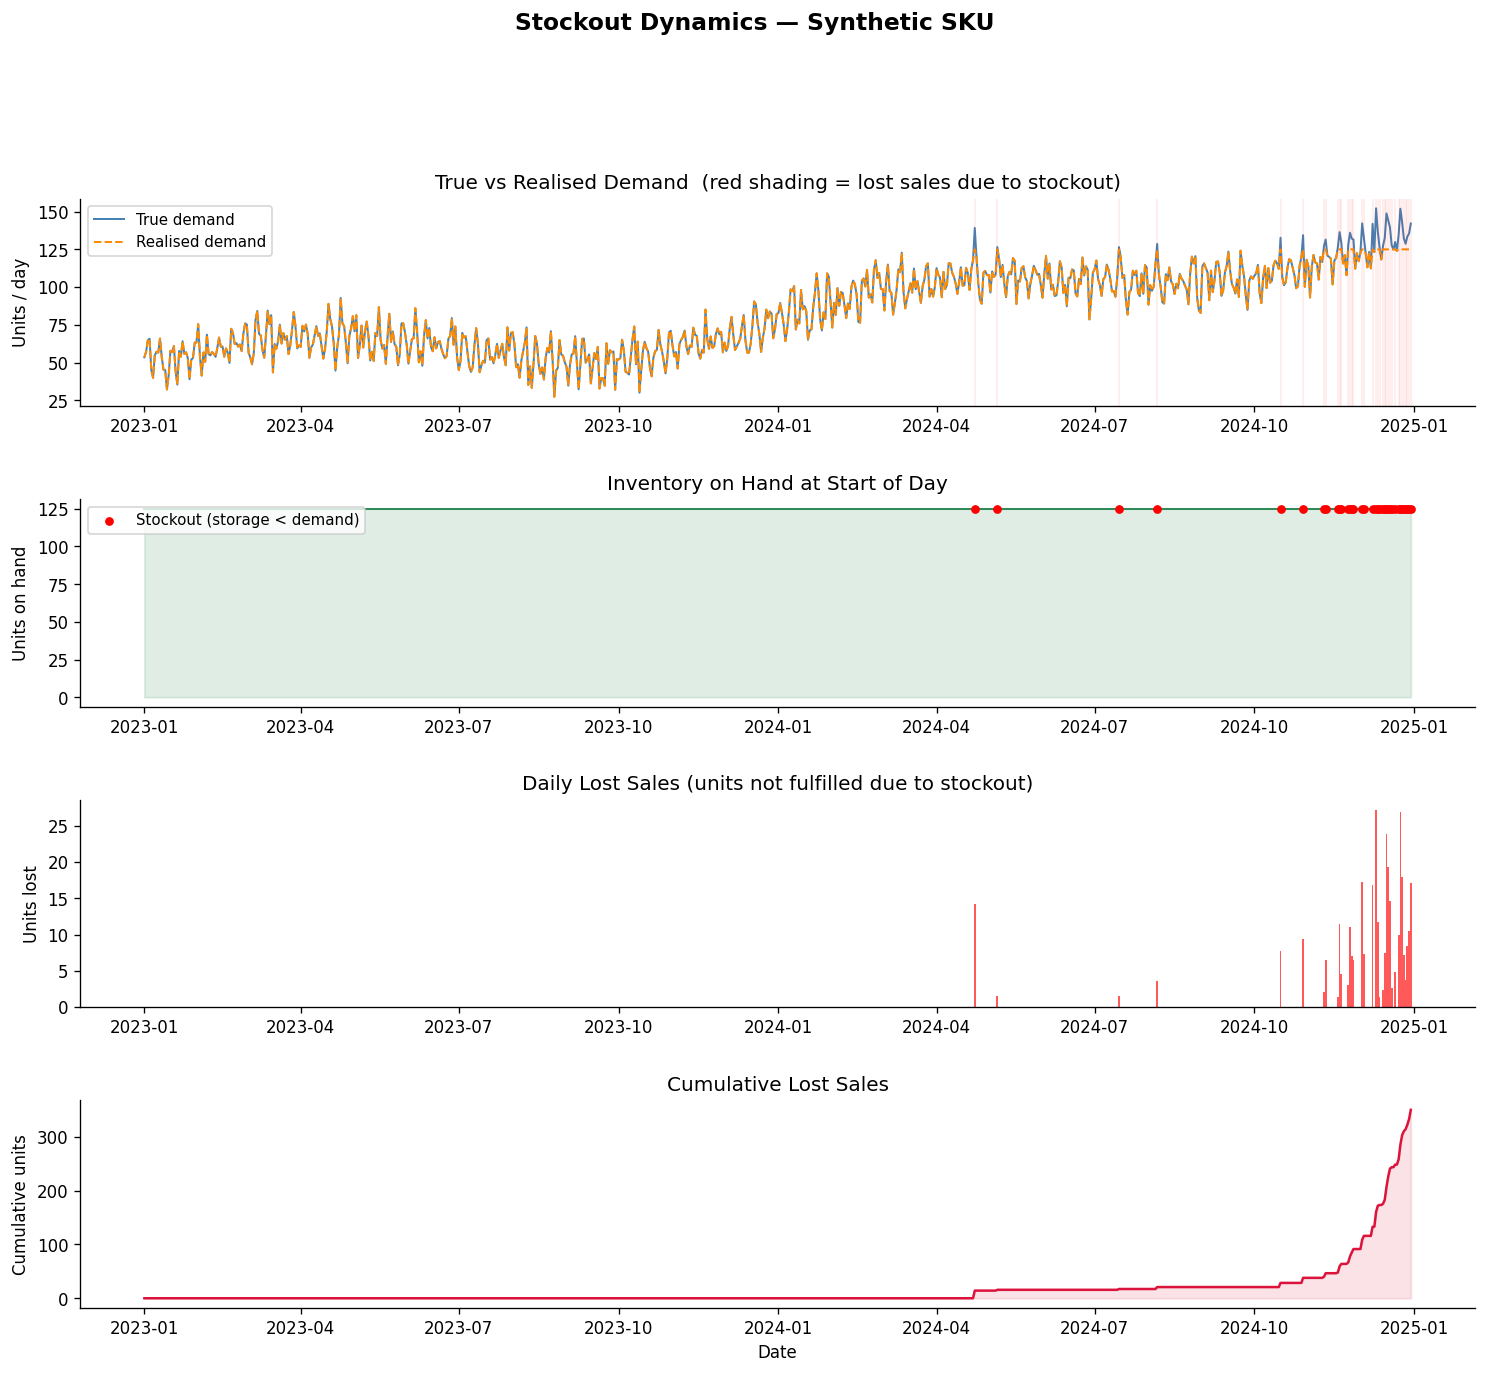

In [3]:
fig = plt.figure(figsize=(15, 12))
gs  = GridSpec(4, 1, figure=fig, hspace=0.45)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax4 = fig.add_subplot(gs[3], sharex=ax1)

# ── Panel 1: True vs Realised demand ──────────────────────────────────────
ax1.plot(df["date"], df["true_demand"],     lw=1.2, color="steelblue",  label="True demand")
ax1.plot(df["date"], df["realised_demand"], lw=1.2, color="darkorange", label="Realised demand", ls="--")

for _, row in df[df["stockout"]].iterrows():
    ax1.axvline(row["date"], color="red", alpha=0.08, lw=1)
ax1.set_ylabel("Units / day")
ax1.set_title("True vs Realised Demand  (red shading = lost sales due to stockout)")
ax1.legend(loc="upper left", fontsize=9)

# ── Panel 2: Inventory on hand ────────────────────────────────────────────
ax2.plot(df["date"], df["storage"], lw=1.2, color="seagreen")
ax2.fill_between(df["date"], 0, df["storage"], color="seagreen", alpha=0.15)
# Mark stockout days
ax2.scatter(
    df.loc[df["stockout"], "date"],
    df.loc[df["stockout"], "storage"],
    color="red", s=18, zorder=5, label="Stockout (storage < demand)"
)
ax2.set_ylabel("Units on hand")
ax2.set_title("Inventory on Hand at Start of Day")
ax2.legend(loc="upper left", fontsize=9)

# ── Panel 3: Daily lost sales ─────────────────────────────────────────────
ax3.bar(df["date"], df["lost_sales"], color="red", alpha=0.65, width=1)
ax3.set_ylabel("Units lost")
ax3.set_title("Daily Lost Sales (units not fulfilled due to stockout)")

# ── Panel 4: Cumulative lost sales ────────────────────────────────────────
ax4.plot(df["date"], df["lost_sales"].cumsum(), lw=1.5, color="crimson")
ax4.fill_between(df["date"], 0, df["lost_sales"].cumsum(), color="crimson", alpha=0.12)
ax4.set_ylabel("Cumulative units")
ax4.set_title("Cumulative Lost Sales")
ax4.set_xlabel("Date")

plt.suptitle("Stockout Dynamics — Synthetic SKU", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. Demand Censoring

A subtle but important point: when a stockout occurs, **the true demand is unobservable** — you only see what was sold (realised demand). This is called *censored demand* or *lost-sales censoring*.

If a forecaster is trained on sales data (realised demand) rather than true demand, it will **underestimate** future demand, leading to systematically low order quantities and a self-reinforcing cycle of stockouts.

The plot below illustrates the gap between the two series and its effect on a naive forecast.

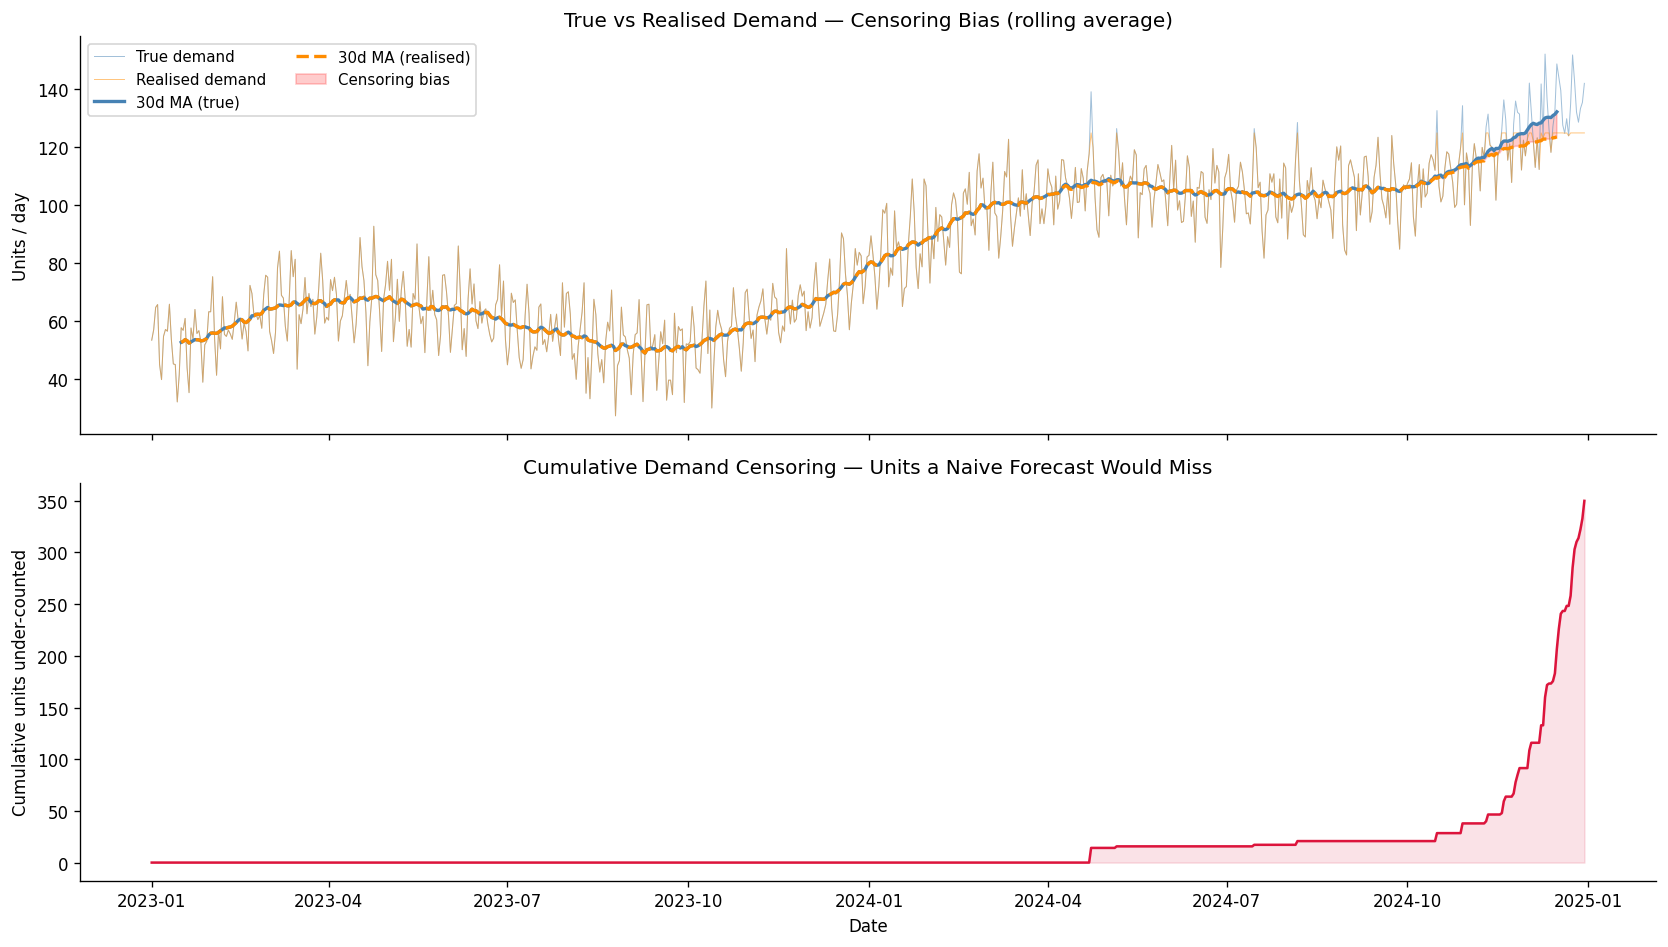

Annual censoring bias: 0.58% of true demand is invisible to a naive forecaster


In [4]:
# Rolling 30-day mean of true demand vs realised demand
window = 30
true_roll     = df["true_demand"].rolling(window, center=True).mean()
realised_roll = df["realised_demand"].rolling(window, center=True).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Raw series
ax1.plot(df["date"], df["true_demand"],     lw=0.6, color="steelblue",  alpha=0.5, label="True demand")
ax1.plot(df["date"], df["realised_demand"], lw=0.6, color="darkorange", alpha=0.5, label="Realised demand")
ax1.plot(df["date"], true_roll,     lw=2,   color="steelblue",  label=f"{window}d MA (true)")
ax1.plot(df["date"], realised_roll, lw=2,   color="darkorange", ls="--", label=f"{window}d MA (realised)")
ax1.fill_between(df["date"], realised_roll, true_roll,
                 where=true_roll > realised_roll,
                 color="red", alpha=0.2, label="Censoring bias")
ax1.set_ylabel("Units / day")
ax1.set_title("True vs Realised Demand — Censoring Bias (rolling average)")
ax1.legend(loc="upper left", fontsize=9, ncol=2)

# Cumulative underestimation
cumulative_bias = (df["true_demand"] - df["realised_demand"]).cumsum()
ax2.plot(df["date"], cumulative_bias, lw=1.5, color="crimson")
ax2.fill_between(df["date"], 0, cumulative_bias, color="crimson", alpha=0.12)
ax2.set_ylabel("Cumulative units under-counted")
ax2.set_title("Cumulative Demand Censoring — Units a Naive Forecast Would Miss")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

bias_pct = (df["true_demand"].sum() - df["realised_demand"].sum()) / df["true_demand"].sum()
print(f"Annual censoring bias: {bias_pct:.2%} of true demand is invisible to a naive forecaster")

---
## Summary

| Concept | Key insight |
|---|---|
| **Stockout mechanics** | Realised demand = `min(true_demand, storage)`; the gap is lost sales |
| **Non-linear growth** | A convex demand curve means a policy adequate in Year 1 becomes chronically insufficient in Year 2 |
| **Demand censoring** | On stockout days the sales record shows `storage`, not true demand; a naive forecaster learns the wrong signal |
| **SSM correction** | Masking stockout days as `NaN` lets the Kalman filter skip those observations and interpolate through the gap, recovering the true trend |
| **Linear model correction** | Passing `stockout_dates` to `BayesTimeSeries` switches the likelihood to `pm.Censored` — a right-censored Normal that integrates over unobserved demand above the cap |

### Next steps — Sections 3 & 4 below
- **Section 3** fits a **Bayesian structural state space model** — biased (raw data) vs corrected (NaN-masked).
- **Section 4** fits a **linear Bayesian model** (`BayesTimeSeries`) — biased (raw data) vs corrected (`pm.Censored`).

---
## 3. Fitting the State Space Model

We fit a **Bayesian structural state space model** — local linear trend + weekly seasonality — to the two-year sales history under two conditions:

| Model | Training data | Expected behaviour |
|---|---|---|
| **Model 1 — Biased** | Raw `realised_demand` (stockout caps included) | Learns the censored signal; underestimates demand growth in Year 2 |
| **Model 2 — Corrected** | `realised_demand` with stockout days → `NaN` | Kalman filter skips censored observations; better recovery of true trend |

**Why does NaN-masking work?**  
At each time step the Kalman filter performs a *predict* step (propagate state forward) and an *update* step (condition on the new observation). When an observation is `NaN` the update step is skipped — the filter simply propagates its current uncertainty forward. This means the model *interpolates* through stockout gaps rather than *learning from* the artificially capped values.

> Both models use `trend_innovations_order=[0, 1]` (drifting slope) so the non-linear growth can be captured. Weekly seasonality is fixed (`seasonal_innovations=False`) since the shape of the weekly pattern doesn't change — only the level does.

Each fit takes a few minutes on CPU.

In [5]:
from optistock.forecasting.state_space import UnivariateSSM

# Model 1: raw realised demand — censored values on stockout days are treated as truth
df_raw = df.set_index("date")[["realised_demand"]].copy()

ssm_raw = UnivariateSSM(data=df_raw, target_col="realised_demand")
ssm_raw.build_model(
    trend_order=2,
    trend_innovations_order=[0, 1],   # drifting slope captures the non-linear growth
    seasonal_period=7,
    seasonal_harmonics=3,
    seasonal_innovations=False,       # weekly pattern is structurally stable
)
ssm_raw.fit(sampler="nutpie", draws=500, tune=300, chains=2)
ssm_raw.smooth_and_filter()
print("Model 1 (raw / biased) fitted and smoothed.")

                                Model Requirements                                
                                                                                  
  Variable              Shape    Constraints                          Dimensions  
 ──────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                              ('state_level_trend',)  
  sigma_level_trend     (1,)     Positive                 ('shock_level_trend',)  
  params_seasonal       (6,)                                 ('state_seasonal',)  
  sigma_obs             ()       Positive                                   None  
  P0                    (8, 8)   Positive semi-definite   ('state', 'state_aux')  
                                                                                  
   These parameters should be assigned priors inside a PyMC model block before    
                    calling the build_statespace_graph method.                    

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:92: UserWarning: No frequency was specific on the data's DateTimeIndex.
  warnings.warn(NO_FREQ_INFO_WARNING)
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,800,1,0.69,7
,800,0,0.60,7


c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x1E5B9B2FAE0>), RNG(<Generator(PCG64) at 0x1E5B9B2FBC0>), RNG(<Generator(PCG64) at 0x1E5B9B2FCA0>), RNG(<Generator(PCG64) at 0x1E5B9B2FD80>), RNG(<Generator(PCG64) at 0x1E5B9BD9E00>), RNG(<Generator(PCG64) at 0x1E5BA2E5FC0>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Variables filtered_posterior_observed, predicted_posterior_observed, smoothed_posterior_observed do not contain all hidden states (their last dimension is not 8). They will not be present in the modified idata.


Model 1 (raw / biased) fitted and smoothed.


In [6]:
# Model 2: stockout days masked as NaN — Kalman filter skips those observations
df_nan = df.set_index("date")[["realised_demand"]].copy()
df_nan.loc[df["stockout"].values, "realised_demand"] = np.nan

print(f"Masked {df['stockout'].sum()} stockout observations as NaN "
      f"({df['stockout'].mean():.1%} of all days)\n")

ssm_nan = UnivariateSSM(data=df_nan, target_col="realised_demand")
ssm_nan.build_model(
    trend_order=2,
    trend_innovations_order=[0, 1],
    seasonal_period=7,
    seasonal_harmonics=3,
    seasonal_innovations=False,
)
ssm_nan.fit(sampler="nutpie", draws=500, tune=300, chains=2)
ssm_nan.smooth_and_filter()
print("Model 2 (NaN-masked / corrected) fitted and smoothed.")

Masked 36 stockout observations as NaN (4.9% of all days)



                                Model Requirements                                
                                                                                  
  Variable              Shape    Constraints                          Dimensions  
 ──────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                              ('state_level_trend',)  
  sigma_level_trend     (1,)     Positive                 ('shock_level_trend',)  
  params_seasonal       (6,)                                 ('state_seasonal',)  
  sigma_obs             ()       Positive                                   None  
  P0                    (8, 8)   Positive semi-definite   ('state', 'state_aux')  
                                                                                  
   These parameters should be assigned priors inside a PyMC model block before    
                    calling the build_statespace_graph method.                    

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:92: UserWarning: No frequency was specific on the data's DateTimeIndex.
  warnings.warn(NO_FREQ_INFO_WARNING)
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:175: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,800,2,0.60,7
,800,0,0.52,7


c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:175: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x1E64B2AB3E0>), RNG(<Generator(PCG64) at 0x1E64B2AAEA0>), RNG(<Generator(PCG64) at 0x1E64B2ABBC0>), RNG(<Generator(PCG64) at 0x1E64B2ABCA0>), RNG(<Generator(PCG64) at 0x1E5B18217E0>), RNG(<Generator(PCG64) at 0x1E5B1EA9EE0>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Variables filtered_posterior_observed, predicted_posterior_observed, smoothed_posterior_observed do not contain all hidden states (their last dimension is not 8). They will not be present in the modified idata.


Model 2 (NaN-masked / corrected) fitted and smoothed.


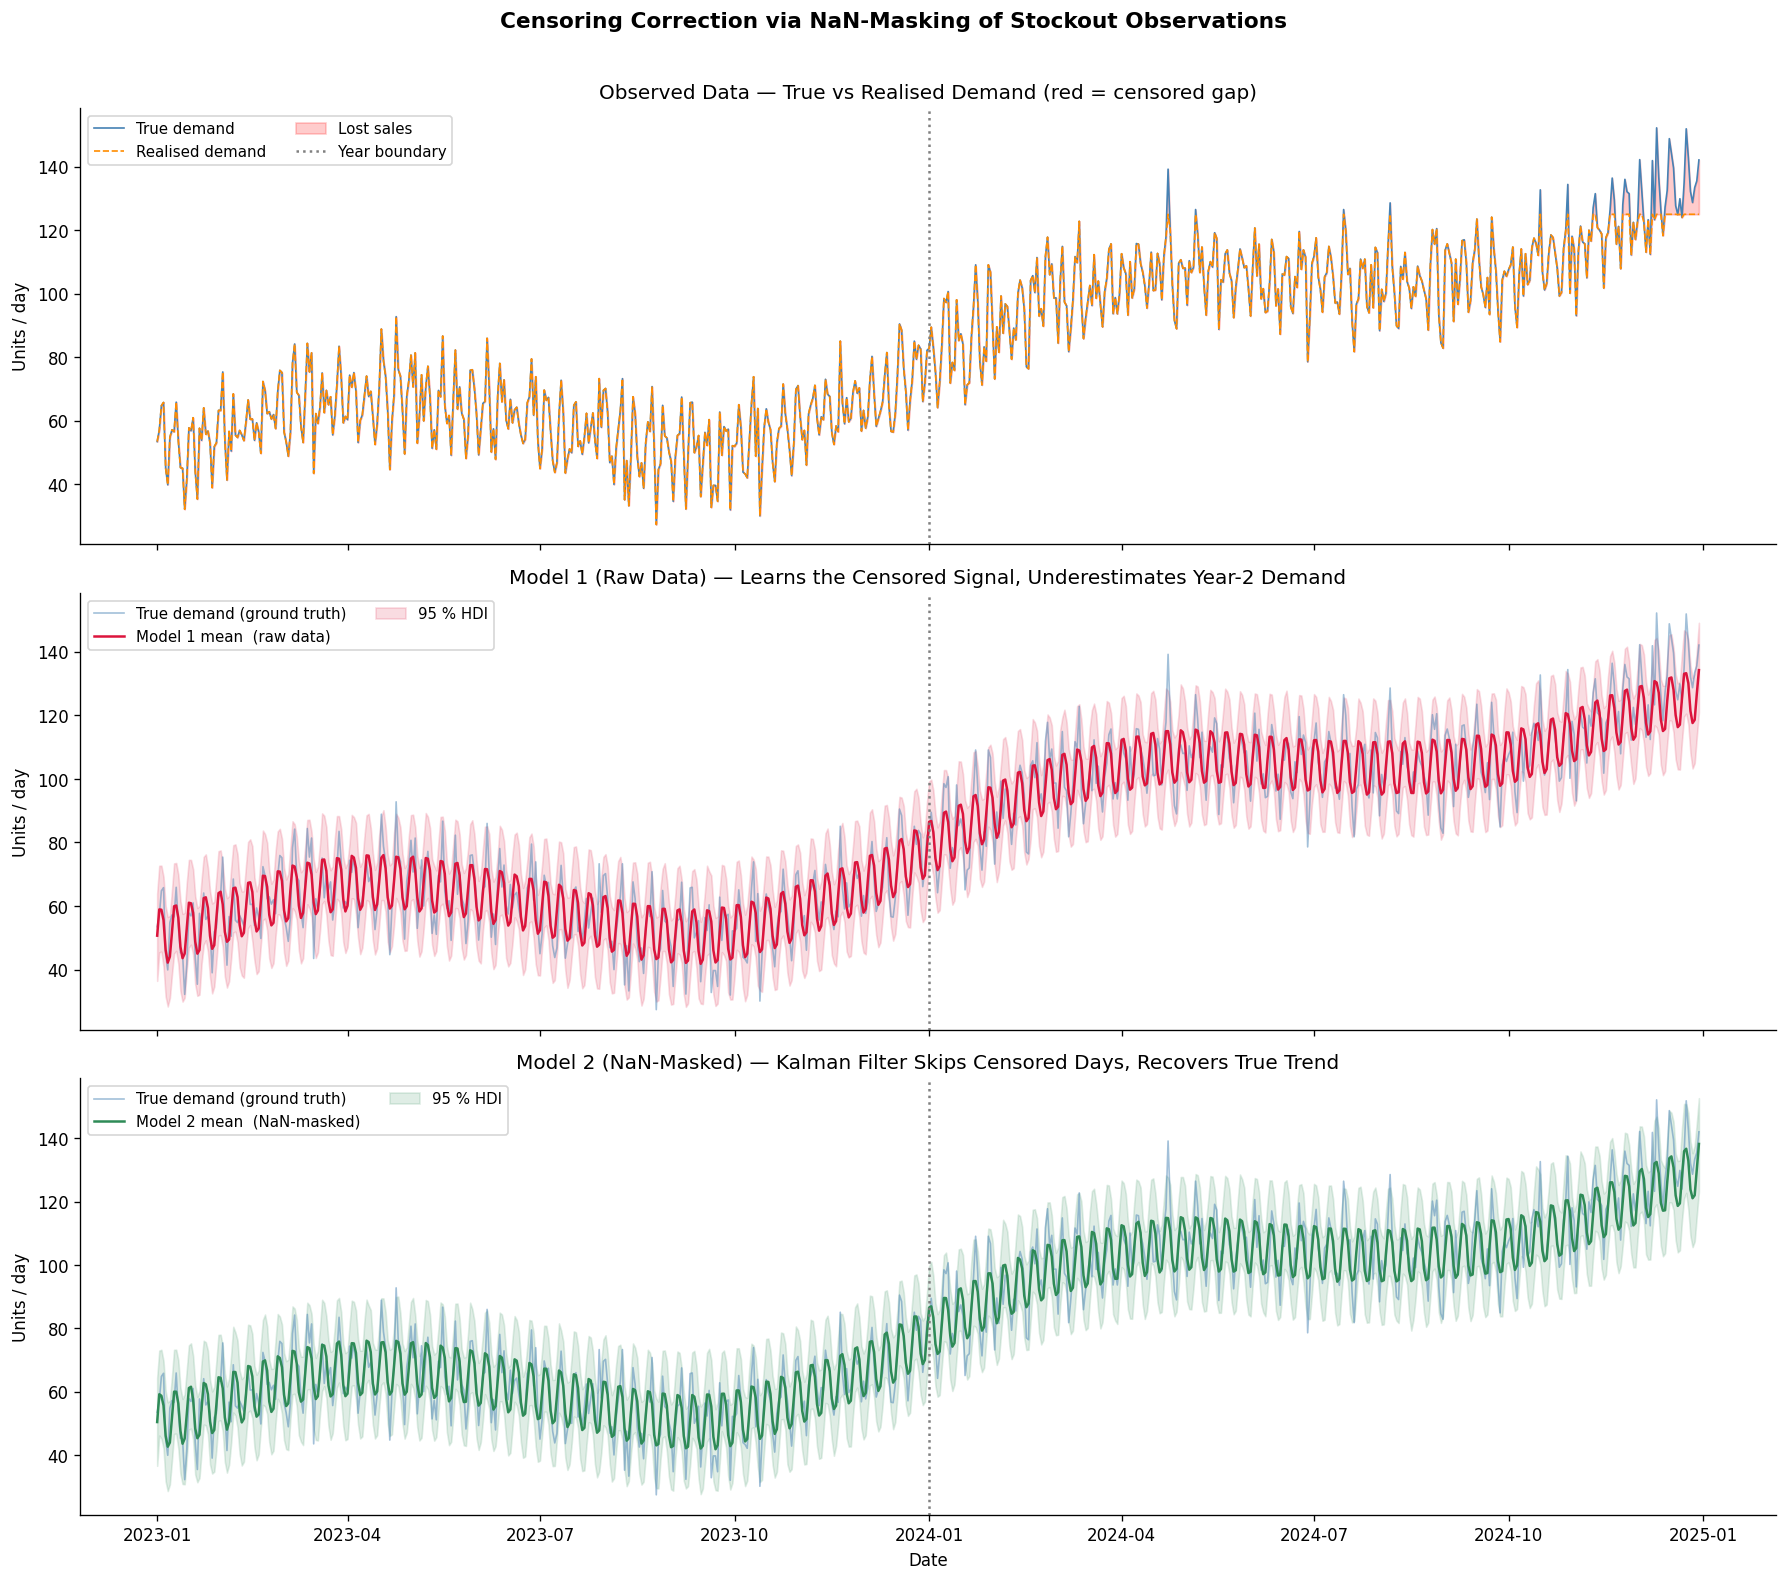

Mean error on stockout days — Model 1 (raw)    : -11.2 units/day
Mean error on stockout days — Model 2 (NaN)    : -9.9 units/day


In [7]:
def _extract_smoothed(ssm_model):
    """Smoothed posterior mean + 95 % HDI in original (unscaled) units."""
    obs = ssm_model.post_idata.smoothed_posterior_observed.isel(observed_state=0)
    s   = obs.stack(sample=["chain", "draw"]) * ssm_model.max_scaler
    return (
        s.mean(dim="sample").values,
        s.quantile(0.025, dim="sample").values,
        s.quantile(0.975, dim="sample").values,
    )


mean_raw, lo_raw, hi_raw = _extract_smoothed(ssm_raw)
mean_nan, lo_nan, hi_nan = _extract_smoothed(ssm_nan)

dates_idx = df.set_index("date").index
true_d    = df["true_demand"].values
real_d    = df["realised_demand"].values
stockout  = df["stockout"].values

year_boundary = dates_idx[365]

fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)
fig.subplots_adjust(hspace=0.42)

# ── Panel 1: Observed data ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(dates_idx, true_d, lw=1.0, color="steelblue",  label="True demand")
ax.plot(dates_idx, real_d, lw=1.0, color="darkorange", ls="--", label="Realised demand")
ax.fill_between(dates_idx, true_d, real_d, color="red", alpha=0.20, label="Lost sales")
ax.axvline(year_boundary, color="grey", ls=":", lw=1.5, label="Year boundary")
ax.set_ylabel("Units / day")
ax.set_title("Observed Data — True vs Realised Demand (red = censored gap)")
ax.legend(loc="upper left", fontsize=9, ncol=2)

# ── Panel 2: Model 1 (biased) vs true demand ──────────────────────────────
ax = axes[1]
ax.plot(dates_idx, true_d,   lw=1.0, color="steelblue", alpha=0.5, label="True demand (ground truth)")
ax.plot(dates_idx, mean_raw, lw=1.5, color="crimson",   label="Model 1 mean  (raw data)")
ax.fill_between(dates_idx, lo_raw, hi_raw, color="crimson", alpha=0.15, label="95 % HDI")
ax.axvline(year_boundary, color="grey", ls=":", lw=1.5)
ax.set_ylabel("Units / day")
ax.set_title("Model 1 (Raw Data) — Learns the Censored Signal, Underestimates Year-2 Demand")
ax.legend(loc="upper left", fontsize=9, ncol=2)

# ── Panel 3: Model 2 (corrected) vs true demand ───────────────────────────
ax = axes[2]
ax.plot(dates_idx, true_d,   lw=1.0, color="steelblue", alpha=0.5, label="True demand (ground truth)")
ax.plot(dates_idx, mean_nan, lw=1.5, color="seagreen",  label="Model 2 mean  (NaN-masked)")
ax.fill_between(dates_idx, lo_nan, hi_nan, color="seagreen", alpha=0.15, label="95 % HDI")
ax.axvline(year_boundary, color="grey", ls=":", lw=1.5)
ax.set_ylabel("Units / day")
ax.set_title("Model 2 (NaN-Masked) — Kalman Filter Skips Censored Days, Recovers True Trend")
ax.legend(loc="upper left", fontsize=9, ncol=2)

axes[2].set_xlabel("Date")
plt.suptitle("Censoring Correction via NaN-Masking of Stockout Observations",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Quantify bias on stockout days ────────────────────────────────────────
so_idx = np.where(stockout)[0]
if len(so_idx):
    bias_raw = (mean_raw[so_idx] - true_d[so_idx]).mean()
    bias_nan = (mean_nan[so_idx] - true_d[so_idx]).mean()
    print(f"Mean error on stockout days — Model 1 (raw)    : {bias_raw:+.1f} units/day")
    print(f"Mean error on stockout days — Model 2 (NaN)    : {bias_nan:+.1f} units/day")

---
## 4. Fitting the Linear Bayesian Model

We repeat the comparison using `BayesTimeSeries` — a Fourier-basis linear Bayesian regressor — to show that the censoring problem and its correction are model-agnostic.

| Model | Training data | Likelihood | Expected behaviour |
|---|---|---|---|
| **Model 3 — Biased** | Raw `realised_demand` | `Normal` | Learns the censored signal; underestimates Year-2 demand |
| **Model 4 — Censored** | Raw `realised_demand` + stockout dates | `pm.Censored(Normal)` | Right-censored likelihood on stockout days; recovers true demand |

**Why does `pm.Censored` work?**  
On a stockout day the observed sales value is an *upper bound* on true demand, not an exact observation.
`pm.Censored` replaces the Normal likelihood with its survival function `P(true demand ≥ observed)` on those days,
so the model correctly integrates over all demand levels above the cap rather than being pulled toward the artificially low observation.

> Both models share identical priors, trend, and Fourier seasonality. The only difference is the likelihood on stockout days.

In [8]:
from optistock.forecasting.linear_regressors import BayesTimeSeries

# Both models use the same DataFrame (date column, not as index)
df_bts = df[["date", "realised_demand"]].copy()

# Model 3: raw realised demand — censored values on stockout days treated as truth
bts_raw = BayesTimeSeries(data=df_bts, target_col="realised_demand")
bts_raw.fit(target="realised_demand", chain=2, samples=500)
print("Model 3 (raw / biased) fitted.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 22 seconds.
Sampling: [y]


Output()

Model 3 (raw / biased) fitted.


In [9]:
# Model 4: pm.Censored likelihood on stockout days
stockout_dates = df.loc[df["stockout"], "date"]
print(f"Passing {len(stockout_dates)} stockout dates to the censored model.\n")

bts_cens = BayesTimeSeries(
    data=df_bts,
    target_col="realised_demand",
    stockout_dates=stockout_dates,
)
bts_cens.fit(target="realised_demand", chain=2, samples=500)
print("Model 4 (pm.Censored) fitted.")

Passing 36 stockout dates to the censored model.



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 31 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y]


Output()

Model 4 (pm.Censored) fitted.


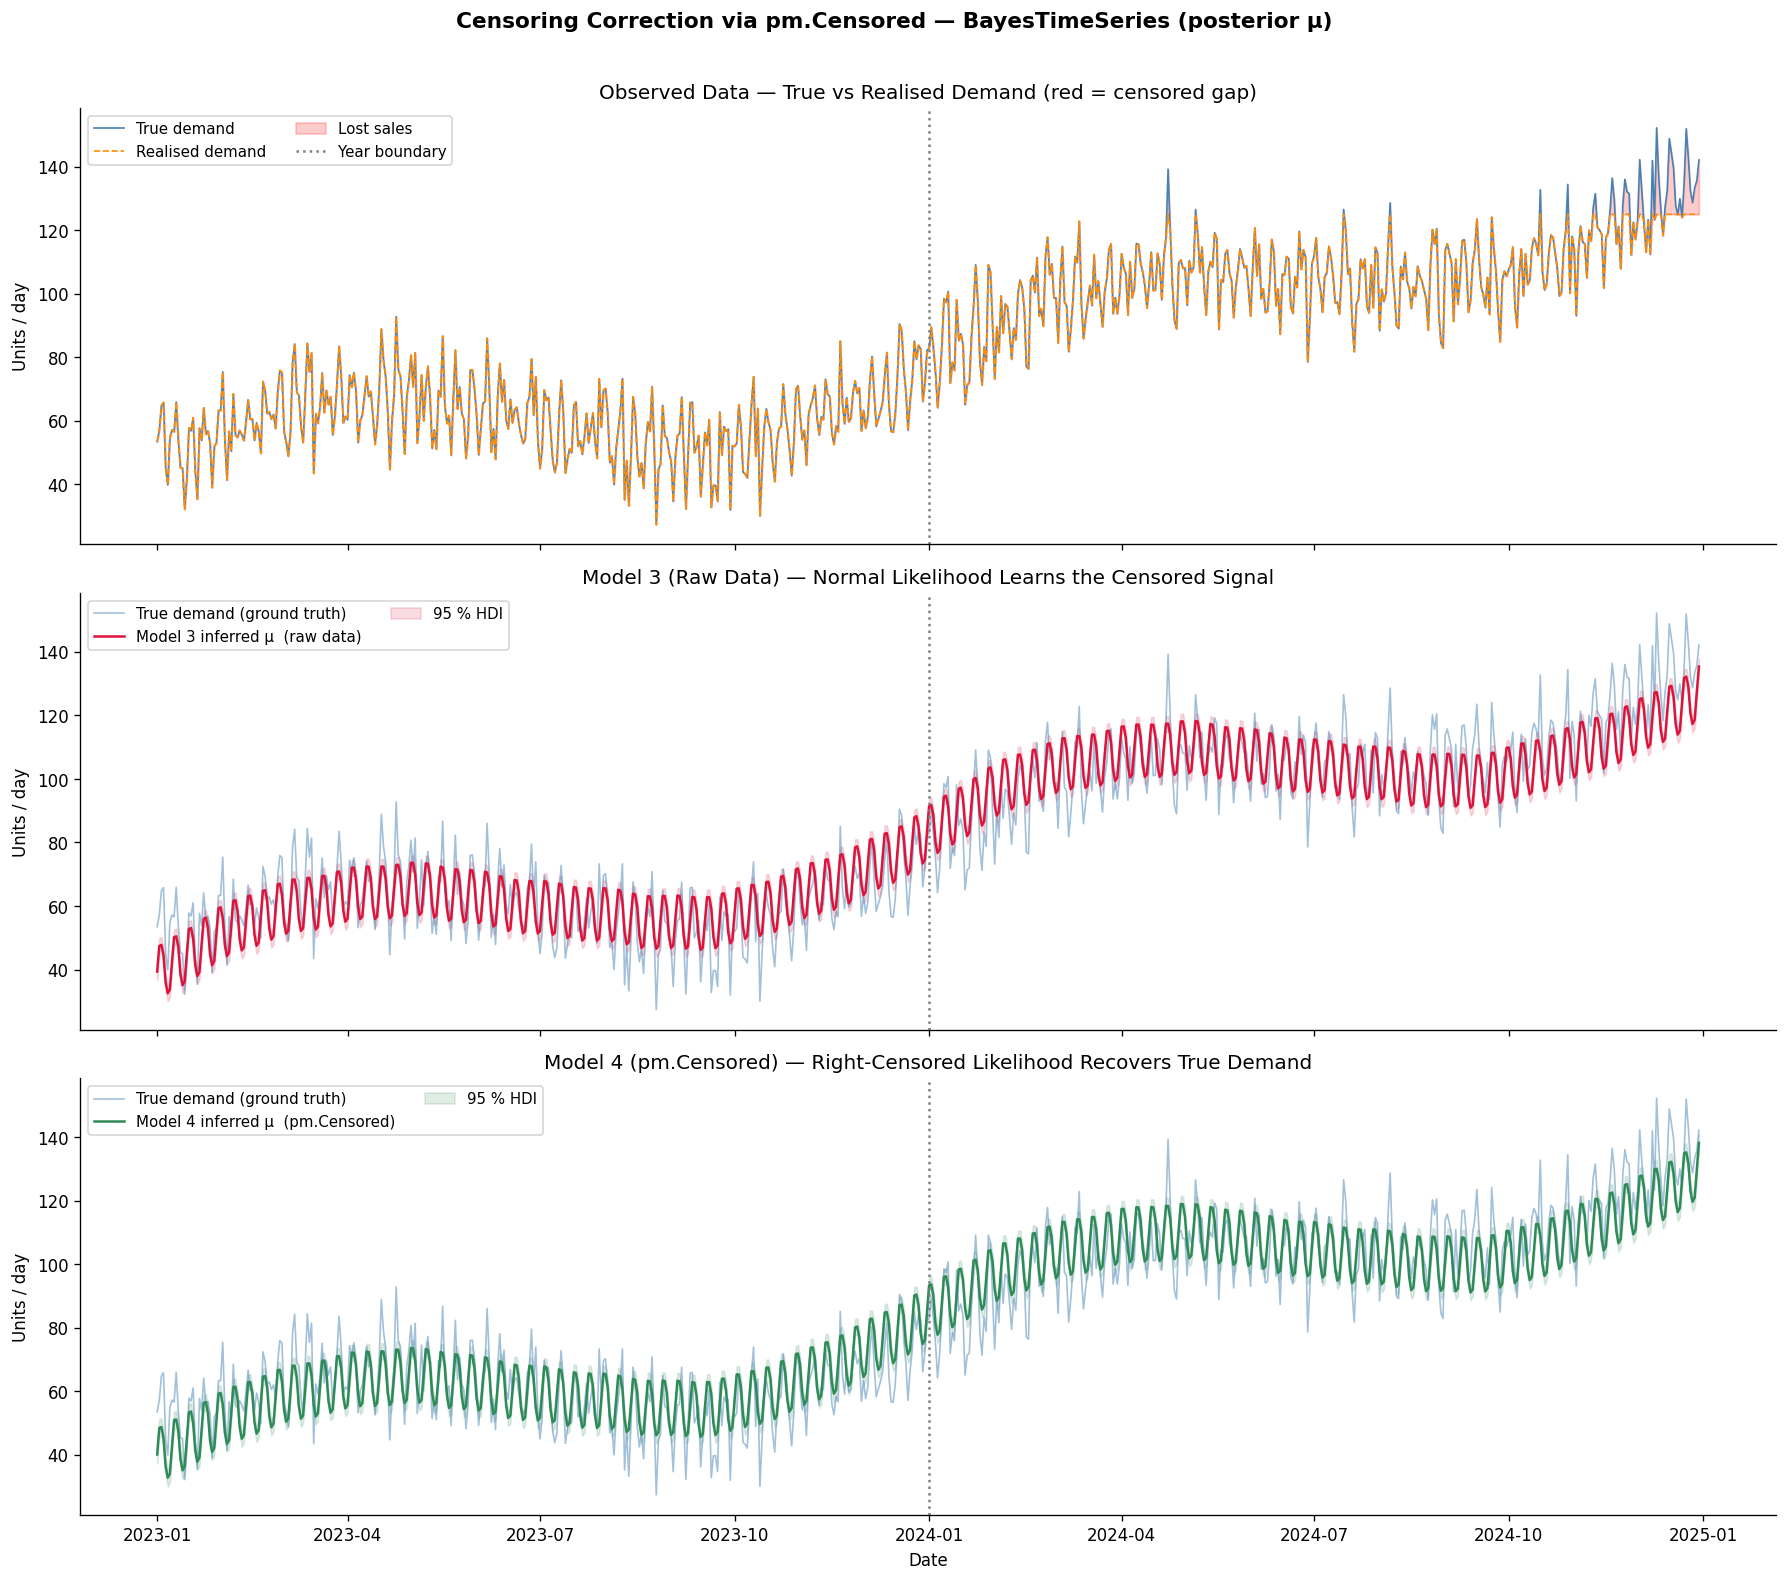

Mean error on stockout days — Model 3 (raw)      : -14.0 units/day
Mean error on stockout days — Model 4 (Censored) : -11.9 units/day


In [13]:
def _extract_bts(bts_model):
    """Posterior mean of the inferred demand (mu) + 95 % HDI in original units.

    Uses idata.posterior["mu"] (the latent deterministic) rather than
    posterior_predictive["y"], because pm.Censored forward-samples are clipped
    at the upper bound — making the censored model appear lower on stockout days.
    mu is uncensored in both models and directly reflects what the likelihood inferred.
    """
    mu = bts_model.idata.posterior["mu"] * bts_model.max_scaler
    return (
        mu.mean(dim=["chain", "draw"]).values,
        mu.quantile(0.025, dim=["chain", "draw"]).values,
        mu.quantile(0.975, dim=["chain", "draw"]).values,
    )


mean_raw_bts,  lo_raw_bts,  hi_raw_bts  = _extract_bts(bts_raw)
mean_cens_bts, lo_cens_bts, hi_cens_bts = _extract_bts(bts_cens)

dates_idx     = df["date"].values
true_d        = df["true_demand"].values
real_d        = df["realised_demand"].values
stockout      = df["stockout"].values
year_boundary = df["date"].iloc[365]

fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)
fig.subplots_adjust(hspace=0.42)

# ── Panel 1: Observed data ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(dates_idx, true_d, lw=1.0, color="steelblue",  label="True demand")
ax.plot(dates_idx, real_d, lw=1.0, color="darkorange", ls="--", label="Realised demand")
ax.fill_between(dates_idx, true_d, real_d, color="red", alpha=0.20, label="Lost sales")
ax.axvline(year_boundary, color="grey", ls=":", lw=1.5, label="Year boundary")
ax.set_ylabel("Units / day")
ax.set_title("Observed Data — True vs Realised Demand (red = censored gap)")
ax.legend(loc="upper left", fontsize=9, ncol=2)

# ── Panel 2: Model 3 (biased) — inferred mu vs true demand ────────────────
ax = axes[1]
ax.plot(dates_idx, true_d,        lw=1.0, color="steelblue", alpha=0.5, label="True demand (ground truth)")
ax.plot(dates_idx, mean_raw_bts,  lw=1.5, color="crimson",   label="Model 3 inferred μ  (raw data)")
ax.fill_between(dates_idx, lo_raw_bts, hi_raw_bts, color="crimson", alpha=0.15, label="95 % HDI")
ax.axvline(year_boundary, color="grey", ls=":", lw=1.5)
ax.set_ylabel("Units / day")
ax.set_title("Model 3 (Raw Data) — Normal Likelihood Learns the Censored Signal")
ax.legend(loc="upper left", fontsize=9, ncol=2)

# ── Panel 3: Model 4 (censored) — inferred mu vs true demand ──────────────
ax = axes[2]
ax.plot(dates_idx, true_d,         lw=1.0, color="steelblue", alpha=0.5, label="True demand (ground truth)")
ax.plot(dates_idx, mean_cens_bts,  lw=1.5, color="seagreen",  label="Model 4 inferred μ  (pm.Censored)")
ax.fill_between(dates_idx, lo_cens_bts, hi_cens_bts, color="seagreen", alpha=0.15, label="95 % HDI")
ax.axvline(year_boundary, color="grey", ls=":", lw=1.5)
ax.set_ylabel("Units / day")
ax.set_title("Model 4 (pm.Censored) — Right-Censored Likelihood Recovers True Demand")
ax.legend(loc="upper left", fontsize=9, ncol=2)

axes[2].set_xlabel("Date")
plt.suptitle("Censoring Correction via pm.Censored — BayesTimeSeries (posterior μ)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Quantify bias on stockout days ────────────────────────────────────────
so_idx = np.where(stockout)[0]
if len(so_idx):
    bias_raw_bts  = (mean_raw_bts[so_idx]  - true_d[so_idx]).mean()
    bias_cens_bts = (mean_cens_bts[so_idx] - true_d[so_idx]).mean()
    print(f"Mean error on stockout days — Model 3 (raw)      : {bias_raw_bts:+.1f} units/day")
    print(f"Mean error on stockout days — Model 4 (Censored) : {bias_cens_bts:+.1f} units/day")